# [LAB 09] 4. 다중선형회귀
## #01. 준비작업
### 1. 라이브러리 참조

In [1]:
# 라이브러리 참조
from hossam import load_data
from helpers import *

import numpy as np
from pandas import DataFrame
from IPython.display import display, Markdown

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.21

⚠️  'hossam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.21, 최신 버전: 0.5.23)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade hossam



### 2. 데이터 불러오기
- 이 데이터는 표준화가 되어있다.
    - 실습의 편의를 위해 품질점검과 탐색적 데이터 분석을 거쳐서 이미 모델링에 투입할 최종 변수가 채택된 상태라고 가정한다.

In [2]:
origin = load_data('sk-diabetes')
origin.head()

📚 442명의 당뇨병 환자를 대상으로 한 검사 결과 데이터. 독립변수 표준화 적용됨 (출처: sklearn 내장 데이터)

    field    description
--  -------  -----------------------
 0  age      나이
 1  sex      성별
 2  bmi      체질량지수
 3  bp       평균혈압
 4  s1       혈청지표 1
 5  s2       혈청지표 2
 6  s3       혈청지표 3
 7  s4       혈청지표 4
 8  s5       혈청지표 5
 9  s6       혈청지표 6
10  target   1년 후 당뇨병 진행 정도



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038,0.051,0.062,0.022,-0.044,-0.035,-0.043,-0.003,0.020,-0.018,151
1,-0.002,-0.045,-0.051,-0.026,-0.008,-0.019,0.074,-0.039,-0.068,-0.092,75
2,0.085,0.051,0.044,-0.006,-0.046,-0.034,-0.032,-0.003,0.003,-0.026,141
3,-0.089,-0.045,-0.012,-0.037,0.012,0.025,-0.036,0.034,0.023,-0.009,206
4,0.005,-0.045,-0.036,0.022,0.004,0.016,0.008,-0.003,-0.032,-0.047,135


## #02. 다중선형회귀
### 1. 1차 분석

In [3]:
df1 = origin.copy()
fit1 = my_ols.auto_ols(df1, y='target')

#### ▶ 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,s1,-792.176,416.680,411.308,-0.489,-1.901,-1.926,0.058,0.055,0.017,59.203
1,target,s5,751.274,171.900,167.187,0.464,4.370,4.494,0.000,0.000,0.099,10.076
2,target,bmi,519.846,66.533,68.591,0.321,7.813,7.579,0.000,0.000,0.662,1.509
3,target,s2,476.739,339.030,326.508,0.294,1.406,1.460,0.160,0.145,0.026,39.193
4,target,bp,324.385,65.422,66.362,0.200,4.958,4.888,0.000,0.000,0.685,1.459
5,target,sex,-239.816,61.222,59.646,-0.148,-3.917,-4.021,0.000,0.000,0.782,1.278
6,target,s4,177.063,161.476,162.475,0.109,1.097,1.090,0.273,0.276,0.112,8.891
7,target,s3,101.043,212.531,208.455,0.062,0.475,0.485,0.635,0.628,0.065,15.402
8,target,s6,67.627,65.984,63.901,0.042,1.025,1.058,0.306,0.291,0.674,1.485
9,target,age,-10.010,59.749,58.230,-0.006,-0.168,-0.172,0.867,0.864,0.821,1.217


**Note. n = 442. F(10, 431) = 46.27, p < 0.001, R² = 0.518, Adj.R² = 0.507, Durbin_Watson = 2.029**

target를 종속변수로, age, sex, bmi, bp, s1, s2, s3, s4, s5, s6(을)를 독립변수로 한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(10, 431) = 46.27 , p < 0.001, R² = 0.518.

즉, age, sex, bmi, bp, s1, s2, s3, s4, s5, s6는 target의 약 51.77%를 설명하는 것으로 나타났다.

---

#### ▶ 회귀모형 가정 검정

...

√MSE = 54.15 / 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,26.145,0.004,2.710,0.003,False,대립가설 채택 → 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watso,2.029,True,독립성 만족


## #03. 다중 공선성 해결
### 1. 독립변수 이름 리스트 생성
- 컬럼이름에서 target 이라는 키워드와 다른 항목만 추출

In [4]:
xnames = list(df1.columns.difference(['target']))
xnames

['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'sex']

### 2. 다중공선성 제거
- s1 하나를 삭제하는 것으로 다중 공선성문제가 해소된다.

In [5]:
df2 = my_prep.reduce_vif(df1, columns=xnames)
df2.info()

[1단계] s1 제거 (VIF = 59.2)

완료! 남은 변수: ['age', 'bmi', 'bp', 's2', 's3', 's4', 's5', 's6', 'sex']
최대 VIF = 7.82
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s2      442 non-null    float64
 5   s3      442 non-null    float64
 6   s4      442 non-null    float64
 7   s5      442 non-null    float64
 8   s6      442 non-null    float64
 9   target  442 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 34.7 KB


### 3. 2차분석

In [6]:
# 다중공선성이 제거된 데이터(df2)로 분석 수행
fit2 = my_ols.auto_ols(df2, y='target')

#### ▶ 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,528.531,66.577,69.902,0.326,7.939,7.561,0.000,0.000,0.666,1.502
1,target,s5,461.839,80.068,88.396,0.285,5.768,5.225,0.000,0.000,0.460,2.173
2,target,bp,319.763,65.574,66.314,0.198,4.876,4.822,0.000,0.000,0.686,1.457
3,target,s3,-250.597,105.002,92.490,-0.155,-2.387,-2.709,0.017,0.007,0.268,3.737
4,target,sex,-234.156,61.335,60.064,-0.145,-3.818,-3.898,0.000,0.000,0.784,1.275
5,target,s2,-143.282,92.922,92.746,-0.089,-1.542,-1.545,0.124,0.123,0.342,2.927
6,target,s4,70.450,151.883,152.447,0.044,0.464,0.462,0.643,0.644,0.128,7.819
7,target,s6,69.127,66.179,64.228,0.043,1.045,1.076,0.297,0.282,0.674,1.484
8,target,age,-7.915,59.920,58.297,-0.005,-0.132,-0.136,0.895,0.892,0.822,1.217


**Note. n = 442. F(9, 432) = 50.71, p < 0.001, R² = 0.514, Adj.R² = 0.504, Durbin_Watson = 2.014**

target를 종속변수로, age, sex, bmi, bp, s2, s3, s4, s5, s6(을)를 독립변수로 한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(9, 432) = 50.71 , p < 0.001, R² = 0.514.

즉, age, sex, bmi, bp, s2, s3, s4, s5, s6는 target의 약 51.37%를 설명하는 것으로 나타났다.

---

#### ▶ 회귀모형 가정 검정

...

√MSE = 54.32 / 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,25.442,0.003,2.932,0.002,False,대립가설 채택 → 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watso,2.014,True,독립성 만족


## #04. 유의하지 않은 독립변수 제거
### 1. 유의수준 >= 0.05인 변수 제거(1차) → age 제거

In [7]:
df3 = df2.drop(['age'], axis=1)
fit3 = my_ols.auto_ols(df3, y='target')

#### ▶ 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,528.572,66.501,69.792,0.326,7.948,7.574,0.000,0.000,0.666,1.502
1,target,s5,460.809,79.597,87.265,0.285,5.789,5.281,0.000,0.000,0.465,2.152
2,target,bp,318.121,64.311,67.384,0.196,4.947,4.721,0.000,0.000,0.712,1.405
3,target,s3,-251.194,104.786,92.165,-0.155,-2.397,-2.725,0.017,0.007,0.268,3.730
4,target,sex,-234.966,60.958,59.938,-0.145,-3.855,-3.920,0.000,0.000,0.792,1.262
5,target,s2,-144.357,92.460,91.730,-0.089,-1.561,-1.574,0.119,0.116,0.344,2.904
6,target,s4,70.898,151.673,152.037,0.044,0.467,0.466,0.640,0.641,0.128,7.815
7,target,s6,67.974,65.526,63.798,0.042,1.037,1.065,0.300,0.287,0.686,1.459


**Note. n = 442. F(8, 433) = 57.17, p < 0.001, R² = 0.514, Adj.R² = 0.505, Durbin_Watson = 2.014**

target를 종속변수로, sex, bmi, bp, s2, s3, s4, s5, s6(을)를 독립변수로 한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(8, 433) = 57.17 , p < 0.001, R² = 0.514.

즉, sex, bmi, bp, s2, s3, s4, s5, s6는 target의 약 51.37%를 설명하는 것으로 나타났다.

---

#### ▶ 회귀모형 가정 검정

...

√MSE = 54.26 / 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,23.613,0.003,3.055,0.002,False,대립가설 채택 → 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watso,2.014,True,독립성 만족


### 2. 유의수준 >= 0.05인 변수 제거(2차) → s4 제거

In [8]:
df4 = df3.drop(['s4'], axis=1)
fit4 = my_ols.auto_ols(df4, y='target')

#### ▶ 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,527.019,66.358,69.767,0.326,7.942,7.554,0.000,0.000,0.667,1.499
1,target,s5,479.227,69.099,74.439,0.296,6.935,6.438,0.000,0.000,0.615,1.625
2,target,bp,315.447,63.999,66.938,0.195,4.929,4.713,0.000,0.000,0.717,1.394
3,target,s3,-289.404,65.502,61.036,-0.179,-4.418,-4.742,0.000,0.000,0.685,1.460
4,target,sex,-233.091,60.771,59.659,-0.144,-3.836,-3.907,0.000,0.000,0.796,1.257
5,target,s2,-110.925,58.542,62.396,-0.069,-1.895,-1.778,0.059,0.076,0.857,1.166
6,target,s6,70.079,65.312,63.788,0.043,1.073,1.099,0.284,0.273,0.689,1.452


**Note. n = 442. F(7, 434) = 65.42, p < 0.001, R² = 0.513, Adj.R² = 0.506, Durbin_Watson = 2.016**

target를 종속변수로, sex, bmi, bp, s2, s3, s5, s6(을)를 독립변수로 한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(7, 434) = 65.42 , p < 0.001, R² = 0.513.

즉, sex, bmi, bp, s2, s3, s5, s6는 target의 약 51.34%를 설명하는 것으로 나타났다.

---

#### ▶ 회귀모형 가정 검정

...

√MSE = 54.21 / 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,21.730,0.003,3.206,0.003,False,대립가설 채택 → 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watso,2.016,True,독립성 만족


### 3. 유의수준 >= 0.05인 변수 제거(3차) → S6 제거

In [9]:
df5 = df4.drop(['s6'], axis=1)
fit5 = my_ols.auto_ols(df5, y='target')

#### ▶ 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,537.687,65.620,69.618,0.332,8.194,7.723,0.000,0.000,0.683,1.465
1,target,s5,497.947,66.871,71.357,0.308,7.446,6.978,0.000,0.000,0.657,1.521
2,target,bp,327.966,62.937,65.927,0.203,5.211,4.975,0.000,0.000,0.742,1.348
3,target,s3,-291.096,65.495,60.948,-0.180,-4.445,-4.776,0.000,0.000,0.685,1.459
4,target,sex,-227.067,60.522,59.634,-0.140,-3.752,-3.808,0.000,0.000,0.803,1.246
5,target,s2,-102.820,58.063,61.533,-0.064,-1.771,-1.671,0.077,0.095,0.872,1.147


**Note. n = 442. F(6, 435) = 76.11, p < 0.001, R² = 0.512, Adj.R² = 0.505, Durbin_Watson = 2.027**

target를 종속변수로, sex, bmi, bp, s2, s3, s5(을)를 독립변수로 한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(6, 435) = 76.11 , p < 0.001, R² = 0.512.

즉, sex, bmi, bp, s2, s3, s5는 target의 약 51.21%를 설명하는 것으로 나타났다.

---

#### ▶ 회귀모형 가정 검정

...

√MSE = 54.22 / 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,21.040,0.002,3.624,0.002,False,대립가설 채택 → 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watso,2.027,True,독립성 만족


### 4. 유의수준 >= 0.05인 변수 제거(4차) → s2 제거

In [10]:
df6 = df5.drop(['s2'], axis=1)
fit6 = my_ols.auto_ols(df6, y='target')

#### ▶ 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,523.568,65.293,69.113,0.323,8.019,7.576,0.000,0.000,0.693,1.443
1,target,s5,474.290,65.683,68.090,0.293,7.221,6.966,0.000,0.000,0.685,1.461
2,target,bp,326.231,63.084,65.772,0.202,5.171,4.960,0.000,0.000,0.742,1.347
3,target,s3,-289.115,65.646,61.158,-0.179,-4.404,-4.727,0.000,0.000,0.685,1.459
4,target,sex,-235.772,60.469,59.641,-0.146,-3.899,-3.953,0.000,0.000,0.808,1.238


**Note. n = 442. F(5, 436) = 90.26, p < 0.001, R² = 0.509, Adj.R² = 0.503, Durbin_Watson = 1.99**

target를 종속변수로, sex, bmi, bp, s3, s5(을)를 독립변수로 한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(5, 436) = 90.26 , p < 0.001, R² = 0.509.

즉, sex, bmi, bp, s3, s5는 target의 약 50.86%를 설명하는 것으로 나타났다.

---

#### ▶ 회귀모형 가정 검정

...

√MSE = 54.35 / 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,20.713,0.001,4.287,0.001,False,대립가설 채택 → 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watso,1.990,True,독립성 만족


## #05. 회귀계수 표, 모형 적합도, 독립변수 보고

In [11]:
report_df = my_ols.report_variables(fit6, df6, hc3=True)
display(report_df)

display(Markdown(my_ols.report_fitness(fit6)))

display(Markdown(my_ols.report_variables_text(fit6, hc3=True)))

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,523.568,65.293,69.113,0.323,8.019,7.576,0.000,0.000,0.693,1.443
1,target,s5,474.290,65.683,68.090,0.293,7.221,6.966,0.000,0.000,0.685,1.461
2,target,bp,326.231,63.084,65.772,0.202,5.171,4.960,0.000,0.000,0.742,1.347
3,target,s3,-289.115,65.646,61.158,-0.179,-4.404,-4.727,0.000,0.000,0.685,1.459
4,target,sex,-235.772,60.469,59.641,-0.146,-3.899,-3.953,0.000,0.000,0.808,1.238


**Note. n = 442. F(5, 436) = 90.26, p < 0.001, R² = 0.509, Adj.R² = 0.503, Durbin_Watson = 1.99**

target를 종속변수로, sex, bmi, bp, s3, s5(을)를 독립변수로 한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(5, 436) = 90.26 , p < 0.001, R² = 0.509.

즉, sex, bmi, bp, s3, s5는 target의 약 50.86%를 설명하는 것으로 나타났다.

- **sex**의 회귀계수는 **B = -235.77**으로 나타났으며, 이는 **target**에 유의한 요인임을 의미한다. (**t(436) = -3.95**, **p < .001**) 즉, **sex가 1 증가**할 때 target는 평균적으로 **235.77 감소**하는 것으로 해석된다.
- **bmi**의 회귀계수는 **B = 523.57**으로 나타났으며, 이는 **target**에 유의한 요인임을 의미한다. (**t(436) = 7.58**, **p < .001**) 즉, **bmi가 1 증가**할 때 target는 평균적으로 **523.57 증가**하는 것으로 해석된다.
- **bp**의 회귀계수는 **B = 326.23**으로 나타났으며, 이는 **target**에 유의한 요인임을 의미한다. (**t(436) = 4.96**, **p < .001**) 즉, **bp가 1 증가**할 때 target는 평균적으로 **326.23 증가**하는 것으로 해석된다.
- **s3**의 회귀계수는 **B = -289.11**으로 나타났으며, 이는 **target**에 유의한 요인임을 의미한다. (**t(436) = -4.73**, **p < .001**) 즉, **s3가 1 증가**할 때 target는 평균적으로 **289.11 감소**하는 것으로 해석된다.
- **s5**의 회귀계수는 **B = 474.29**으로 나타났으며, 이는 **target**에 유의한 요인임을 의미한다. (**t(436) = 6.97**, **p < .001**) 즉, **s5가 1 증가**할 때 target는 평균적으로 **474.29 증가**하는 것으로 해석된다.

> ※ 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해 **HC3 로버스트 표준오차**로 계산한 값이다. 회귀계수(B)와 효과 크기 해석은 일반 OLS와 동일하며, 표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다.

## #06. 변수 영향력 비교
### 1. 표준화 계수 β를 시각화 하기 위한 전철
- 표준화 계수의 절대값 순위는 종속변수에 미치는 영향력 순위를 의미한다.
    - 영향력의 절대값은 아님

In [12]:
rdf = report_df[['독립변수', 'β']].copy()
rdf['부호'] = np.where(rdf['β'] > 0, '+', '-')
rdf.head()

,독립변수,β,부호
0,bmi,0.323,+
1,s5,0.293,+
2,bp,0.202,+
3,s3,-0.179,-
4,sex,-0.146,-


### 2. 영향력 순위 시각화

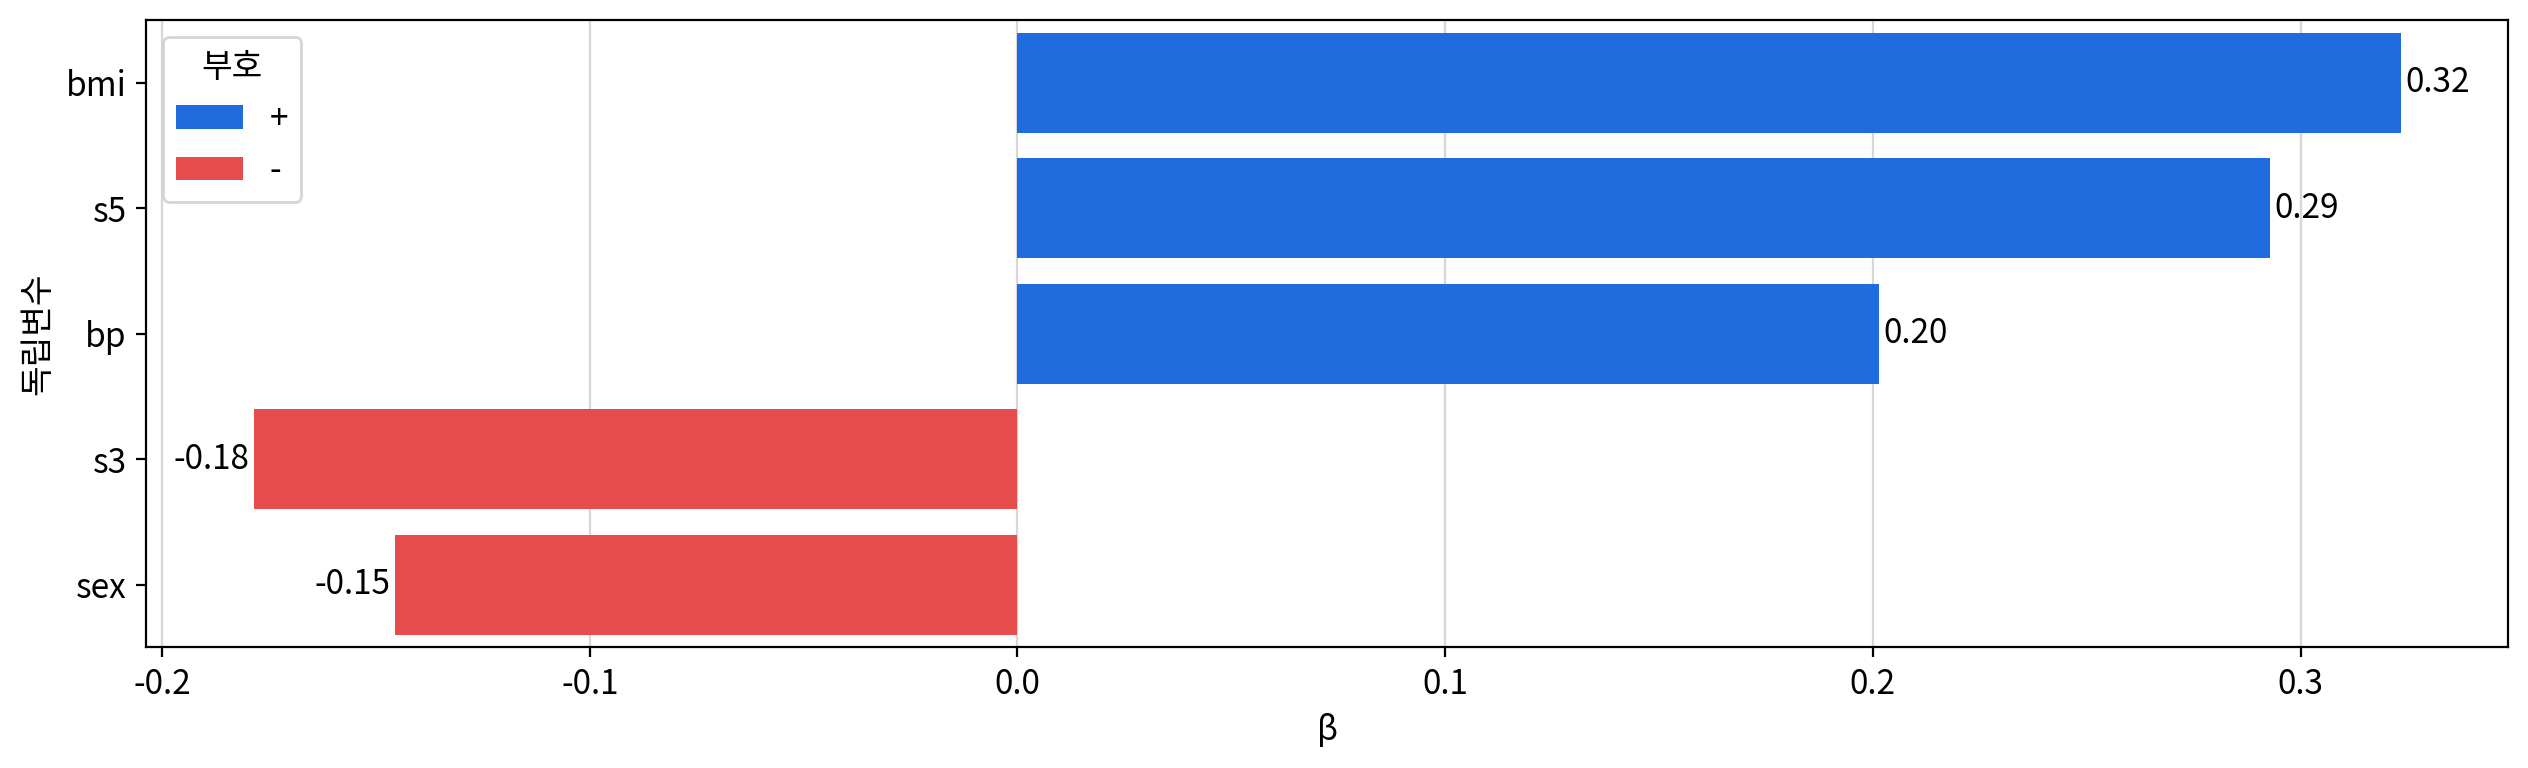

In [13]:
fig, ax = my_plot.init(height=400)
my_plot.barplot(rdf, x='β', y='독립변수', hue='부호', palette={'+':'#0066ff', '-':'#ff3333'}, ax=ax)

for i in rdf.index:
    beta = rdf.loc[i,'β']
    sign = rdf.loc[i,'부호']
    ax.text(x=beta + 0.001 * np.sign(beta), y=i, s=f'{beta:.2f}', va='center', ha='left' if beta > 0 else 'right', color='black')

my_plot.show()

### 3. 시각화 모듈 확인

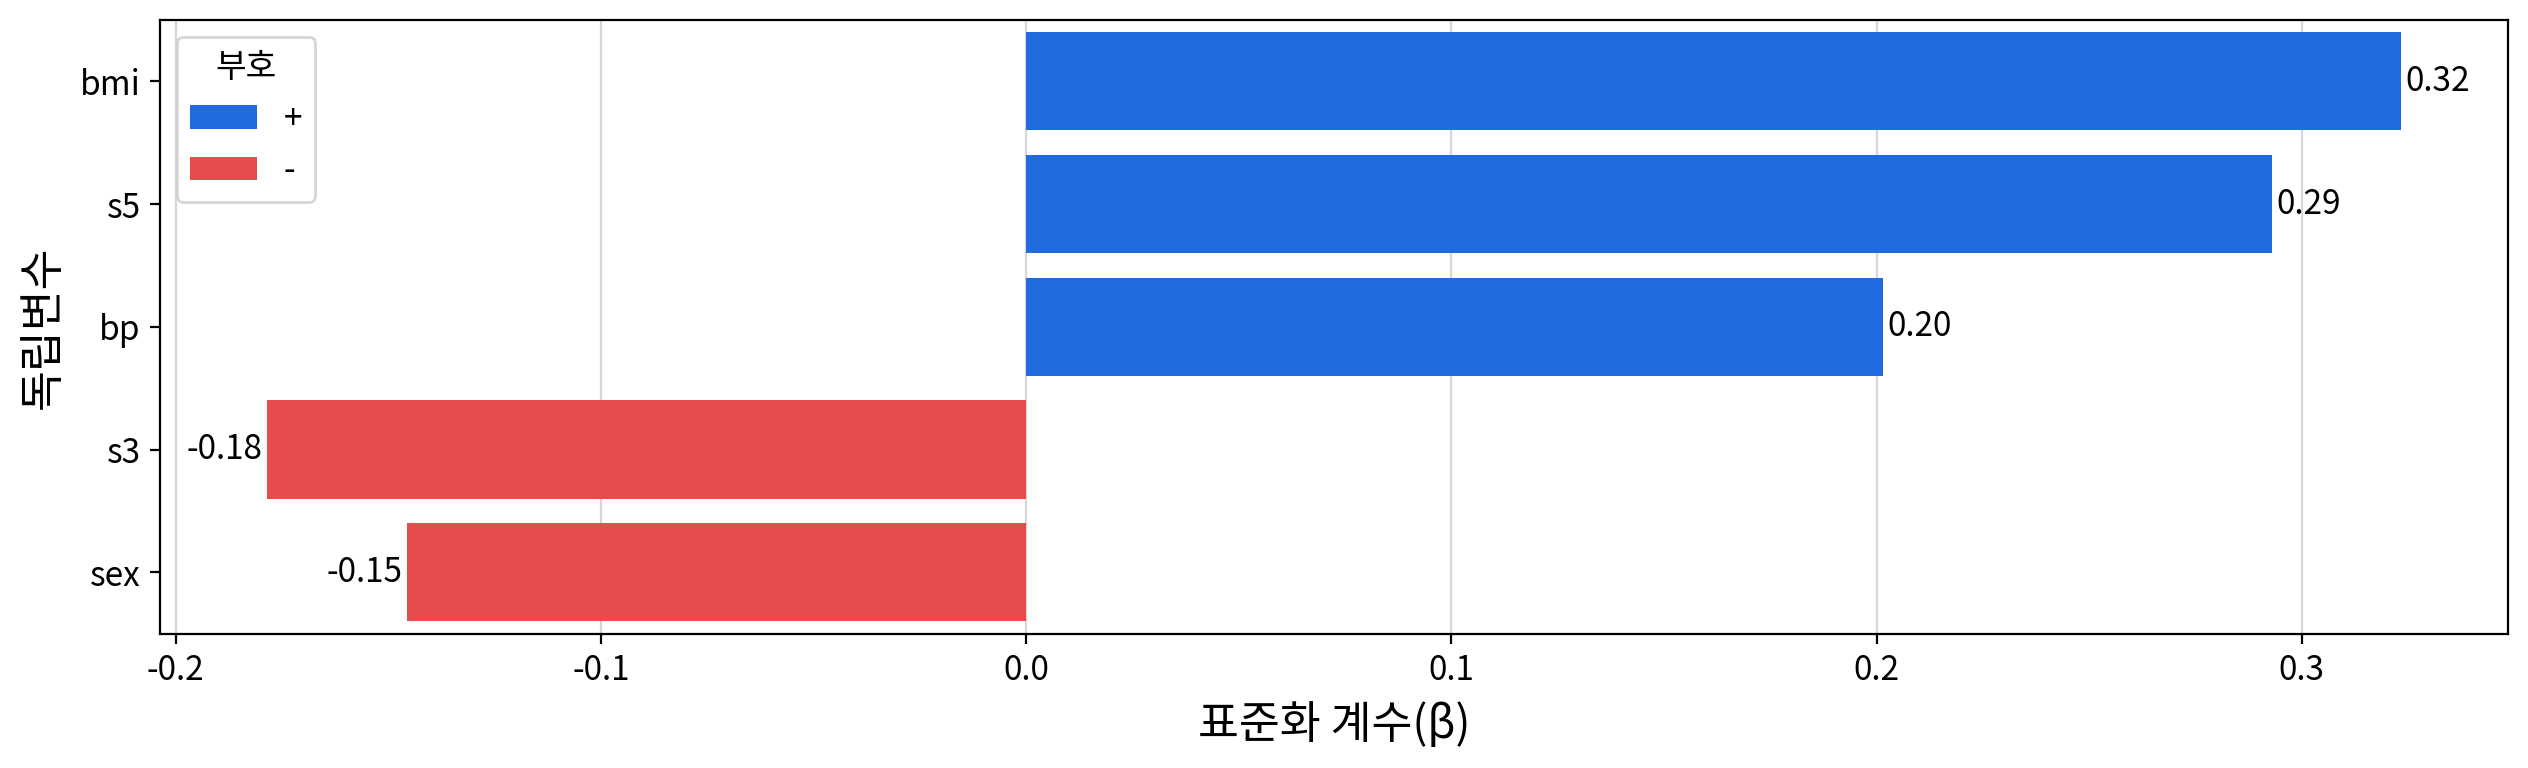

In [14]:
my_ols.plot_beta(fit6, df6)